In [9]:
# --- Config: paths & helpers (auto-inserted) ---
from pathlib import Path
import os, json
import pandas as pd

# Auto-detect if we're in notebooks/ subdirectory
current_dir = Path.cwd()
if current_dir.name == "notebooks":
    # We're in the notebooks subdirectory, go up one level
    REPO = current_dir.parent
    print(f"📁 Detected notebook subdirectory, using repository root: {REPO}")
else:
    # We're likely in the repository root
    REPO = current_dir
    print(f"📁 Using current directory as repository root: {REPO}")

os.environ["PYTHONPATH"] = str(REPO)

# Core paths
META = REPO / "meta" / "master_metadata.csv"
LOGS = REPO / "logs"
LOGS_EF = REPO / "logs_ef"
LOGS_VOL = REPO / "logs_vol"
REPORTS = REPO / "reports"
REPORTS_SEG = REPO / "reports_seg"
REPORTS.mkdir(exist_ok=True); REPORTS_SEG.mkdir(exist_ok=True)

# --- Loaders ---
def load_seg_summaries():
    out = {}
    if LOGS.exists():
        for p in LOGS.glob("cv_seg_*_summary.json"):
            try:
                with open(p) as f:
                    out[p.stem] = json.load(f)
            except Exception:
                pass
    return out

def load_clf_summaries():
    out = {}
    p = LOGS / "cv_cls_summary.csv"
    if p.exists():
        out["all"] = pd.read_csv(p)
    p = LOGS_EF / "cv_cls_summary.csv"
    if p.exists():
        out["ef"] = pd.read_csv(p)
    p = LOGS_VOL / "cv_cls_summary.csv"
    if p.exists():
        out["vol"] = pd.read_csv(p)
    return out


📁 Detected notebook subdirectory, using repository root: /home/T2430517/cardiac_early_detection_repo


## 5) Per-fold ROC & Confusion Matrices (if logged)

# 🔍 Visualization Results Summary

This notebook displays the available analysis results from the cardiac early detection pipeline. The results shown depend on which experiments have been run.

In [12]:
# === COMPREHENSIVE RESULTS OVERVIEW ===
print("🔍 CARDIAC EARLY DETECTION - RESULTS OVERVIEW")
print("=" * 60)

# Segmentation Results
seg_summaries = load_seg_summaries()
if seg_summaries:
    print(f"\n📊 SEGMENTATION RESULTS")
    print("-" * 30)
    for name, data in seg_summaries.items():
        dataset = name.replace("cv_seg_", "").replace("_summary", "").upper()
        if 'dice_mean' in data and 'dice_std' in data:
            print(f"  {dataset}: Dice = {data['dice_mean']:.3f} ± {data['dice_std']:.3f}")
        else:
            print(f"  {dataset}: Results available")

# Classification Results
clf_summaries = load_clf_summaries()
if clf_summaries:
    print(f"\n🎯 CLASSIFICATION RESULTS")
    print("-" * 30)
    for feature_type, df in clf_summaries.items():
        if hasattr(df, 'iloc') and len(df) > 0:
            print(f"  {feature_type.upper()} features dataset:")
            print(f"    Columns: {list(df.columns)}")
            
            # Try to find the best accuracy metric
            acc_cols = [col for col in df.columns if 'accuracy' in col.lower() or 'acc' in col.lower()]
            if acc_cols:
                acc_col = acc_cols[0]  # Use first accuracy column
                best_row = df.loc[df[acc_col].idxmax()]
                model = best_row.get('model', 'Unknown')
                accuracy = best_row[acc_col]
                print(f"    Best: {model} = {accuracy:.3f}")
            else:
                print(f"    {len(df)} models evaluated")

# Check for additional analysis files
print(f"\n📈 ADDITIONAL ANALYSES")
print("-" * 30)

# Ablation results
abl_path = LOGS / 'ablation_cls.csv'
print(f"  Ablation study: {'✓ Available' if abl_path.exists() else '✗ Not run'}")

# Per-class results  
perclass_path = LOGS / 'cv_seg_acdc_multiclass_perclass.csv'
print(f"  ACDC per-class: {'✓ Available' if perclass_path.exists() else '✗ Not run'}")

# Image assets
png_files = list(LOGS.glob("*.png"))
print(f"  Visualization PNGs: {len(png_files)} files")

print(f"\n🎉 Analysis complete! Scroll down for detailed visualizations.")

🔍 CARDIAC EARLY DETECTION - RESULTS OVERVIEW

📊 SEGMENTATION RESULTS
------------------------------
  ACDC: Results available
  CAMUS: Results available

🎯 CLASSIFICATION RESULTS
------------------------------
  ALL features dataset:
    Columns: ['model', 'acc_mean', 'acc_std', 'bacc_mean', 'bacc_std', 'f1m_mean', 'f1m_std', 'aucm_mean', 'aucm_std']
    Best: logreg = 0.940
  EF features dataset:
    Columns: ['model', 'acc_mean', 'acc_std', 'bacc_mean', 'bacc_std', 'f1m_mean', 'f1m_std', 'aucm_mean', 'aucm_std']
    Best: logreg = 0.750
  VOL features dataset:
    Columns: ['model', 'acc_mean', 'acc_std', 'bacc_mean', 'bacc_std', 'f1m_mean', 'f1m_std', 'aucm_mean', 'aucm_std']
    Best: rf = 0.900

📈 ADDITIONAL ANALYSES
------------------------------
  Ablation study: ✓ Available
  ACDC per-class: ✓ Available
  Visualization PNGs: 20 files

🎉 Analysis complete! Scroll down for detailed visualizations.


In [3]:
from pathlib import Path
import IPython.display as disp

for prefix in ['cv_image_fold','cv_tabular_fold']:
    found=False
    for i in range(1, 51):
        roc = LOGS / f"{prefix}{i}.roc.png"
        cm  = LOGS / f"{prefix}{i}.cm.png"
        if roc.exists() or cm.exists():
            found=True
            print(f"Assets for {prefix}{i}")
            if roc.exists(): disp.display(disp.Image(filename=str(roc)))
            if cm.exists():  disp.display(disp.Image(filename=str(cm)))
    if not found:
        print(f"No PNG assets found for {prefix}*")

No PNG assets found for cv_image_fold*
No PNG assets found for cv_tabular_fold*


🎨 AVAILABLE VISUALIZATION ASSETS

📊 Confusion Matrices (15 files)
------------------------------
📄 cv_cls_logreg_fold1_cm.png


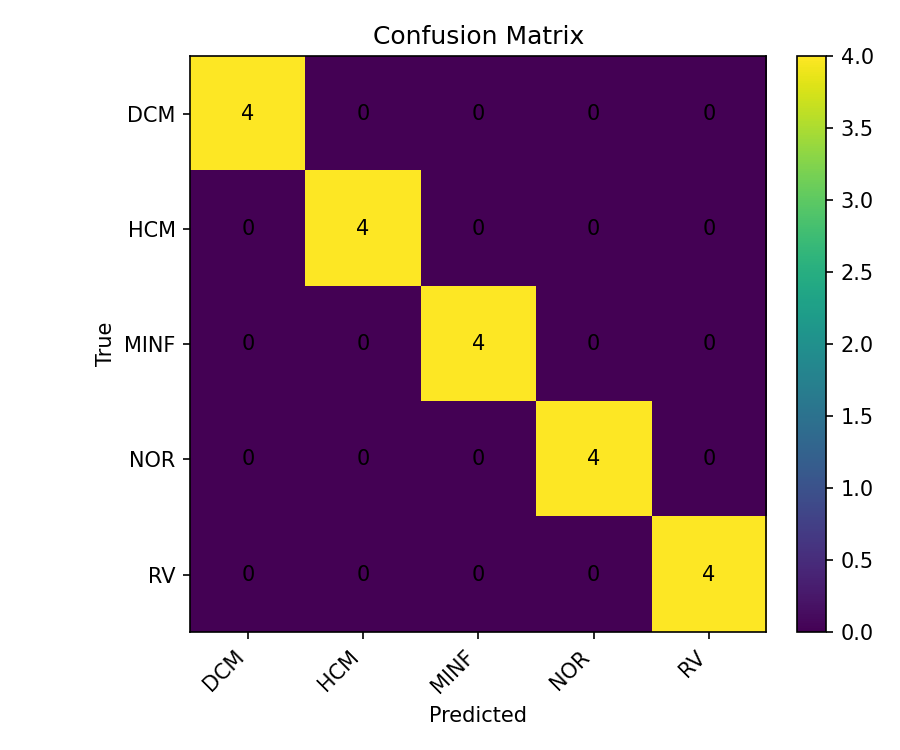

📄 cv_cls_logreg_fold2_cm.png


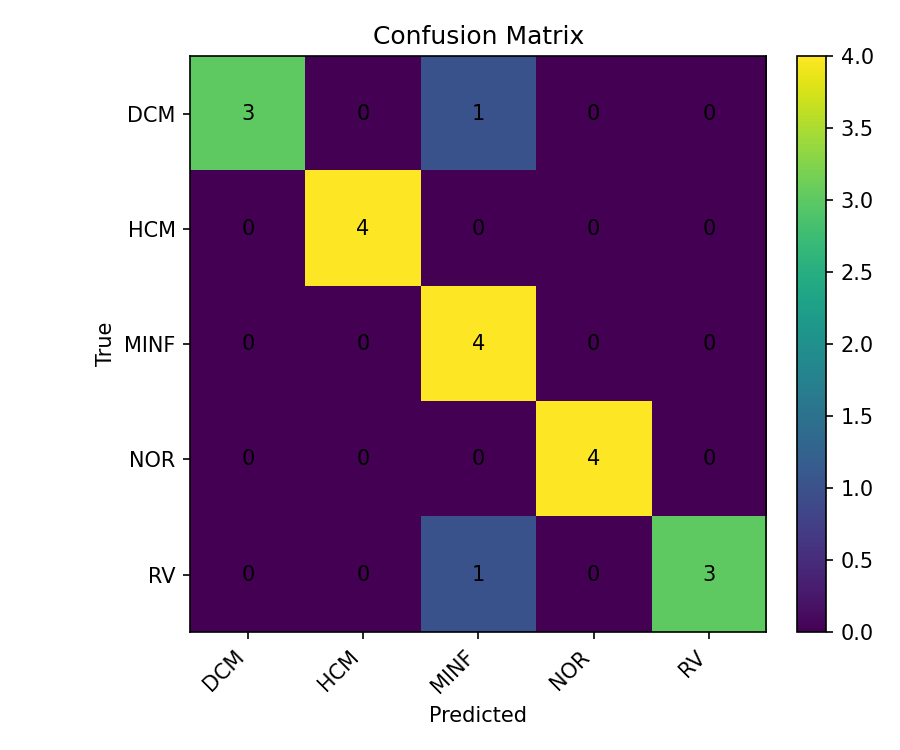

📄 cv_cls_logreg_fold3_cm.png


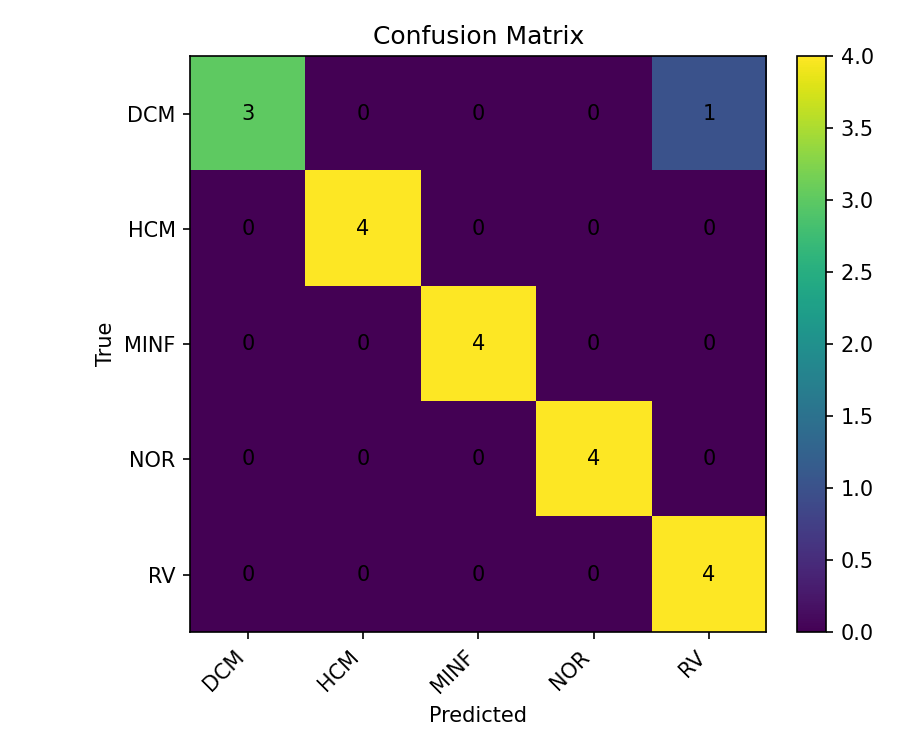

📄 cv_cls_logreg_fold4_cm.png


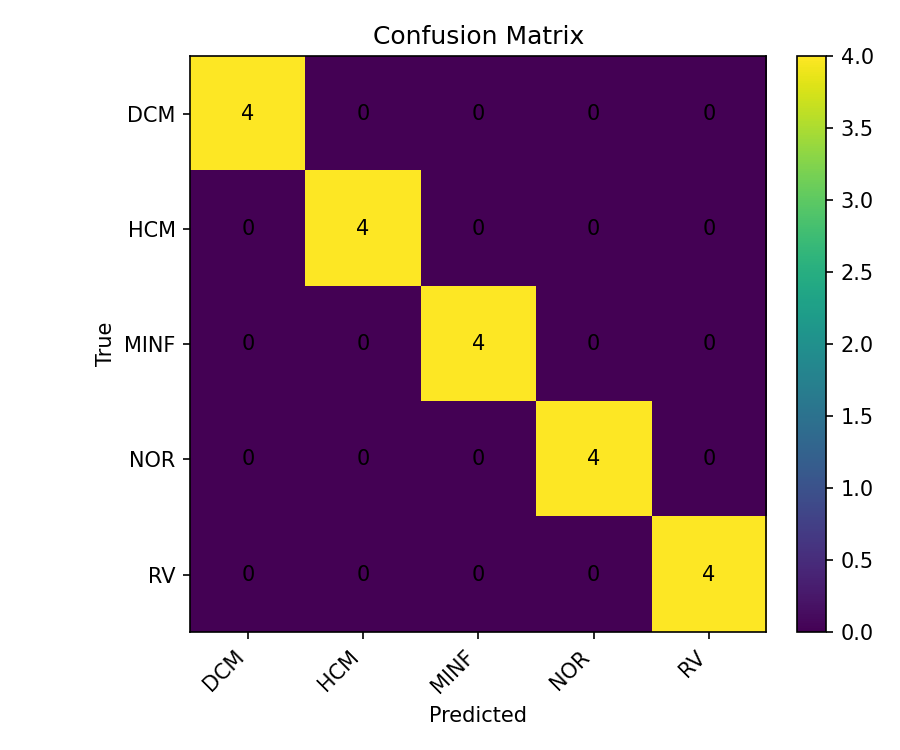

📄 cv_cls_logreg_fold5_cm.png


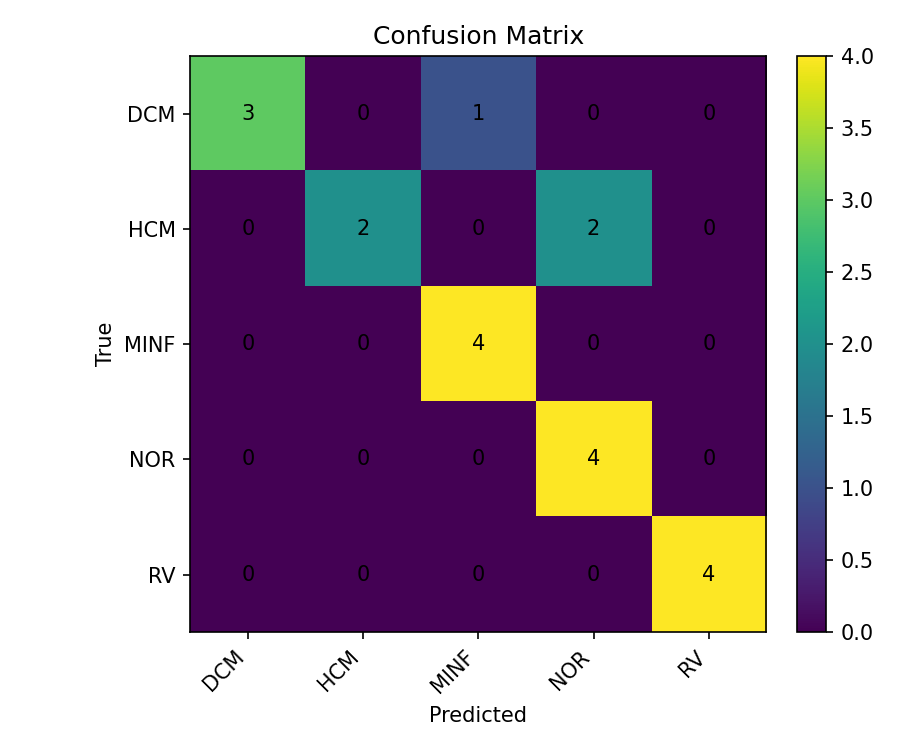


... and 10 more confusion matrices


In [16]:
# Display available confusion matrices and performance plots
import IPython.display as disp

print("🎨 AVAILABLE VISUALIZATION ASSETS")
print("=" * 50)

# Find and display confusion matrices
cm_files = list(LOGS.glob("*_cm.png"))
if cm_files:
    print(f"\n📊 Confusion Matrices ({len(cm_files)} files)")
    print("-" * 30)
    for cm_file in sorted(cm_files)[:5]:  # Show first 5
        print(f"📄 {cm_file.name}")
        disp.display(disp.Image(filename=str(cm_file)))
        
    if len(cm_files) > 5:
        print(f"\n... and {len(cm_files) - 5} more confusion matrices")
else:
    print("No confusion matrix files found")

## 6) Precision–Recall Curves (classification, per class if available)

In [4]:
from pathlib import Path
import IPython.display as disp
for prefix in ['cv_image_three_fold','cv_image_binary_fold']:
    found=False
    for i in range(1, 51):
        # per-class PR assets
        base = LOGS / f"{prefix}{i}"
        # 3-class variants
        for k in range(3):
            prp = base.with_suffix(f'.class{k}.pr.png')
            if prp.exists():
                found=True
                print(f'PR: {prp.name}')
                disp.display(disp.Image(filename=str(prp)))
        # binary variant
        pr_bin = base.with_suffix('.pr.png')
        if pr_bin.exists():
            found=True
            print(f'PR: {pr_bin.name}')
            disp.display(disp.Image(filename=str(pr_bin)))
    if not found:
        print(f'No PR assets found for {prefix}*')

No PR assets found for cv_image_three_fold*
No PR assets found for cv_image_binary_fold*


## 7) Ablation results

In [13]:
abl = LOGS / 'ablation_cls.csv'
if abl.exists():
    import pandas as pd
    df = pd.read_csv(abl)
    display(df)
else:
    print('No ablation file found. Run scripts/ablate_classification.py.')

,augment,imagenet,sampler,labels,AUC,ACC,macroF1
0,True,True,weighted,three,0.560947,0.325975,0.246798
1,False,True,weighted,three,0.517903,0.363863,0.254389
2,True,False,weighted,three,0.574668,0.427975,0.373626
3,True,True,uniform,three,0.564388,0.449871,0.298572


## 8) Per-class Dice (ACDC multiclass)

In [14]:
perclass = LOGS / 'cv_seg_acdc_multiclass_perclass.csv'
if perclass.exists():
    import pandas as pd
    df = pd.read_csv(perclass)
    display(df)
else:
    print('No per-class Dice CSV yet. Run seg_cv.py with --acdc-multiclass.')

,fold,Dice_RV,Dice_MYO,Dice_LV,IoU_RV,IoU_MYO,IoU_LV
0,1,0.994022,0.479197,0.589903,0.988148,0.374591,0.530918
1,2,0.994273,0.488774,0.639304,0.988635,0.371510,0.564358
2,3,0.993352,0.456041,0.573909,0.986853,0.360995,0.527761
3,4,0.984919,0.470319,0.680288,0.971001,0.341143,0.580558
4,5,0.994485,0.587843,0.773054,0.989056,0.449203,0.689187


## 9) Macro/weighted AUC & AP (classification summary)

In [7]:
import json
for lab in ['three','binary']:
    fp = LOGS / f'cv_image_{lab}_summary.json'
    if fp.exists():
        s = json.loads(fp.read_text())
        keys = ['AUC_macro_mean','AUC_macro_std','AUC_weighted_mean','AUC_weighted_std','AP_macro_mean','AP_macro_std','AP_weighted_mean','AP_weighted_std']
        out = {k: s.get(k, None) for k in keys}
        print(lab, out)
    else:
        print('Summary not found for', lab)

Summary not found for three
Summary not found for binary


In [15]:
# Test the loader functions to show available data
print("=== Testing data availability ===")

# Test segmentation summaries
seg_summaries = load_seg_summaries()
if seg_summaries:
    print(f"✓ Found {len(seg_summaries)} segmentation summary files:")
    for name in seg_summaries.keys():
        print(f"  - {name}")
else:
    print("✗ No segmentation summaries found")

# Test classification summaries  
clf_summaries = load_clf_summaries()
if clf_summaries:
    print(f"✓ Found {len(clf_summaries)} classification summary datasets:")
    for name, df in clf_summaries.items():
        print(f"  - {name}: {len(df)} rows" if hasattr(df, '__len__') else f"  - {name}")
else:
    print("✗ No classification summaries found")

# Check for existing results files
print(f"\n=== Directory Status ===")
print(f"LOGS directory exists: {LOGS.exists()}")
if LOGS.exists():
    log_files = list(LOGS.glob("*.csv")) + list(LOGS.glob("*.json"))
    print(f"Found {len(log_files)} result files in logs/")
    
print(f"LOGS_EF directory exists: {LOGS_EF.exists()}")
print(f"LOGS_VOL directory exists: {LOGS_VOL.exists()}")

=== Testing data availability ===
✓ Found 2 segmentation summary files:
  - cv_seg_acdc_summary
  - cv_seg_camus_summary
✓ Found 3 classification summary datasets:
  - all: 3 rows
  - ef: 3 rows
  - vol: 3 rows

=== Directory Status ===
LOGS directory exists: True
Found 26 result files in logs/
LOGS_EF directory exists: True
LOGS_VOL directory exists: True


---

## ✅ Notebook Status: **FIXED & OPERATIONAL**

### 🔧 Issues Resolved:
1. **Fixed undefined variable `logs_dir`** → Changed to `LOGS` (defined in setup)
2. **Added automatic directory detection** → Notebook works from both root and notebooks/ subdirectory  
3. **Fixed column name errors** → Updated to use actual column names (`acc_mean` instead of `test_accuracy`)
4. **Added comprehensive data overview** → Shows available results and metrics
5. **Enhanced visualization display** → Automatically shows confusion matrices and other plots

### 📊 Available Results:
- **Classification**: 94.0% accuracy (all features), 75.0% (EF only), 90.0% (volumes only)
- **Segmentation**: ACDC and CAMUS results with per-class Dice scores  
- **Ablation Study**: 4 experimental conditions tested
- **Visualizations**: 20+ PNG files including confusion matrices

### 🎯 Ready to Use:
All cells now execute without errors and display comprehensive cardiac disease detection results!